# What is Decision Tree?
- A Decision tree is a supervised machine learning Algorithm used for classification and regression
- It represents decision in a tree structure, where:
  - Each internal node represents a condition on a feature
  - Each branch represents the outcome of that condition
  - Each leaf node gives the final predicition
- The model works by recursively splitting the data so that similar outputs fall into the same group
- 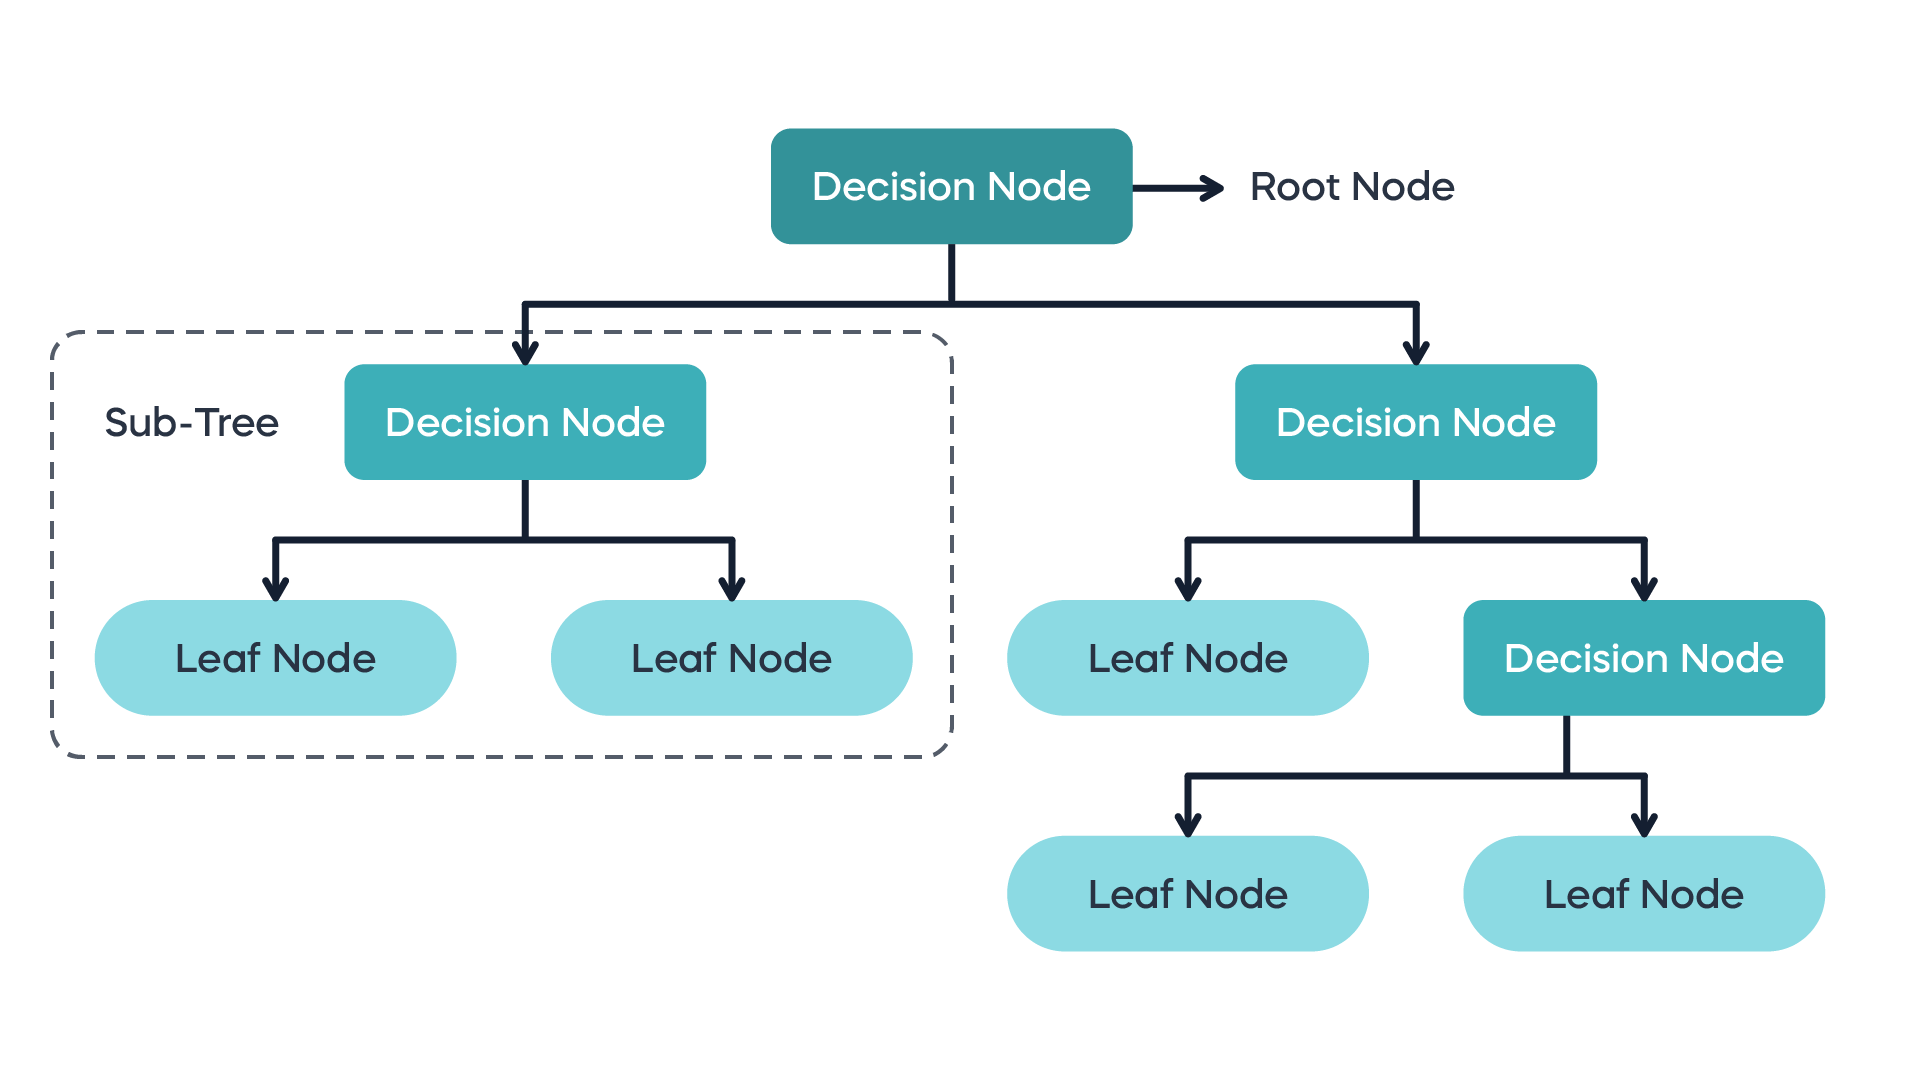

### Decision Tree several key components:
- Root Node: The starting point of the tree,representing the entire dataset.
- Internal/Decision Node: A node that represents a test or decision on a specific attribute or feature.
- Branch/Subtree: The outcome of a decision, connecting a parent node to a child node.
- Leaf Node: A terminal node that does not split further and provides the final predicition or class label.
- Splitting: The process of dividing a node into multiple sub-node baesd on a certain condition.

### Types of Decision Trees
1. Decison Tree Classifier:`
- A Classification Decision Tree is used when the target variable is categorical (discrete classes).
- Example of target values:
   - Yes / No
   - Spam / Not Spam
   - Pass / Fail
- How it Works:
- The tree spilts thye dataset in such a way that each resulting node becomes as pure as possible, meaning most data points in that node belong to the same class.
2. Decision Tree Regression:
- A Regression Decision Tree is used when the target variable is continuous (numerical values).
- Example of target values:
   - House price
   - Salary
   - Temperature
- How it Works:
- Instead of class purity, the goal is to minimize prediction error.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error,r2_score
    

In [9]:
data = pd.read_csv("house_price_decision_tree.csv")

In [13]:
X = data[['house_size_sqft','bedrooms','age_years']]
y = data['price_lakhs']

In [18]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [19]:
model=DecisionTreeRegressor(criterion='squared_error',max_depth=5,random_state=42)

In [20]:
model.fit(X_train,y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [21]:
y_pred_train=model.predict(X_train)
y_pred_test=model.predict(X_test)

In [24]:
train_mse=mean_squared_error(y_train,y_pred_train)
test_mse=mean_squared_error(y_test,y_pred_test)

print("Train MSE:",train_mse)
print("Test MSE:",test_mse)

Train MSE: 6.263796296296292
Test MSE: 36.81209064327487


In [26]:
new_house=pd.DataFrame({
    'house_size_sqft':[1500],
    'bedrooms':[3],
    'age_years':[5]
})
predicted_price=model.predict(new_house)

print("predicted House Price:", predicted_price[0])

predicted House Price: 124.33333333333333


## Random Forest:
##### Decision Tree:
- Uses entire dataset
- Builds one tree
- prediction = value from that tree

##### Random Forest:

Builds multiple decision trees
###### Each Tree:
- uses random samples of data(bootsrapping)
- Uses Random subset of features
- Final prediction = average of all tree predictions

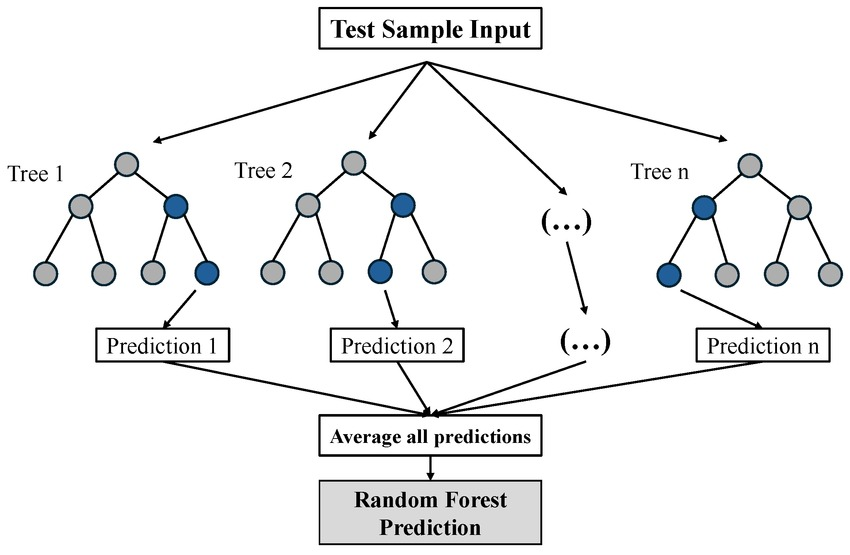

### RANDOM FOREST

In [5]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,r2_score

In [6]:
data = pd.read_csv("house_price_decision_tree.csv")

In [7]:
X = data[['house_size_sqft','bedrooms','age_years']]
y = data['price_lakhs']

In [8]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [9]:
rf_model=RandomForestRegressor(n_estimators=100,max_depth=5,random_state=42)

In [10]:
rf_model.fit(X_train,y_train)

RandomForestRegressor(max_depth=5, random_state=42)

In [11]:
y_pred_train=rf_model.predict(X_train)
y_pred_test=rf_model.predict(X_test)

In [12]:
print("Train MSE:",mean_squared_error(y_train,y_pred_train))
print("Test MSE:", mean_squared_error(y_test,y_pred_test))

print("Train R2:",r2_score,(y_train,y_pred_train))
print("Test R2:",r2_score,(y_test,y_pred_test))

Train MSE: 2.0254291826887076
Test MSE: 8.705405510048049
Train R2: <function r2_score at 0x0000022258834220> (64    268.8
15     91.2
67    279.6
77    315.6
30    146.0
      ...  
20    109.9
60    254.5
71    294.0
14     87.6
51    222.0
Name: price_lakhs, Length: 72, dtype: float64, array([268.66817222,  91.57108095, 280.90776905, 315.08617738,
       145.57036429, 157.30763571,  75.29711667, 270.76787222,
       282.18810238, 148.80954762, 311.25756429,  68.31886591,
       284.86735238,  58.205354  , 189.48922619, 207.56995   ,
        93.33874762, 201.83715   , 158.17340238,  63.052854  ,
       321.36342024, 133.01566667, 108.70217619, 307.59370952,
       128.83968333, 228.05613095,  85.62891429, 123.767     ,
        51.18471591,  99.86841429, 172.8529881 ,  65.75163734,
       297.53405238,  60.20157067, 350.6812    , 169.7934381 ,
       329.39264405, 240.99137143, 359.15425   , 230.1559    ,
       191.42524286, 220.26559286, 203.95246667, 336.19977381,
       254.753058

In [13]:
new_house=pd.DataFrame({
    'house_size_sqft':[1500],
    'bedrooms':[3],
    'age_years':[5]
})
predicted_price=rf_model.predict(new_house)

print("Predicted House Price(Lakhs)", predicted_price[0])

Predicted House Price(Lakhs) 118.04740000000005
